--- Starting FGSM Adversarial Attack (VisDrone Multi-Class) ---
TensorFlow Version: 2.20.0
Extracting...

Folder structure:
VisDrone2019-DET-val -> ['.DS_Store']
VisDrone2019-DET-val/annotations -> ['0000199_01269_d_0000166.txt', '0000277_01601_d_0000547.txt', '0000312_01201_d_0000420.txt', '0000276_01201_d_0000513.txt', '0000333_02941_d_0000016.txt']
VisDrone2019-DET-val/images -> ['0000295_00800_d_0000025.jpg', '0000001_08414_d_0000013.jpg', '0000346_00001_d_0000346.jpg', '0000287_01001_d_0000764.jpg', '0000021_00800_d_0000003.jpg']

Loading crops for car / truck / motor / background...
Class counts: {'background': 548, 'car': 3903, 'truck': 282, 'motor': 208}
Training class counts: {'background': 434, 'car': 3114, 'truck': 230, 'motor': 174}
Test class counts: {'background': 114, 'car': 789, 'truck': 52, 'motor': 34}
Class weights: {0: np.float64(2.2764976958525347), 1: np.float64(0.31727681438664096), 2: np.float64(4.2956521739130435), 3: np.float64(5.67816091954023)}

Training ref

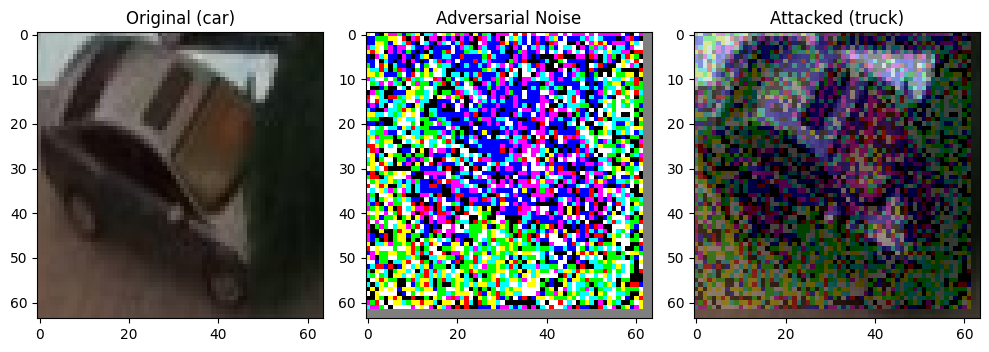


Running FGSM across epsilon values on the full test set...
epsilon=0.00 | acc=0.601 | precision=0.448 | recall=0.635 | FPR=0.121
epsilon=0.01 | acc=0.321 | precision=0.343 | recall=0.397 | FPR=0.200
epsilon=0.03 | acc=0.119 | precision=0.243 | recall=0.172 | FPR=0.259
epsilon=0.05 | acc=0.051 | precision=0.134 | recall=0.099 | FPR=0.277
epsilon=0.10 | acc=0.019 | precision=0.031 | recall=0.052 | FPR=0.276
epsilon=0.15 | acc=0.005 | precision=0.005 | recall=0.021 | FPR=0.272
epsilon=0.20 | acc=0.006 | precision=0.007 | recall=0.026 | FPR=0.269
epsilon=0.30 | acc=0.024 | precision=0.017 | recall=0.113 | FPR=0.261


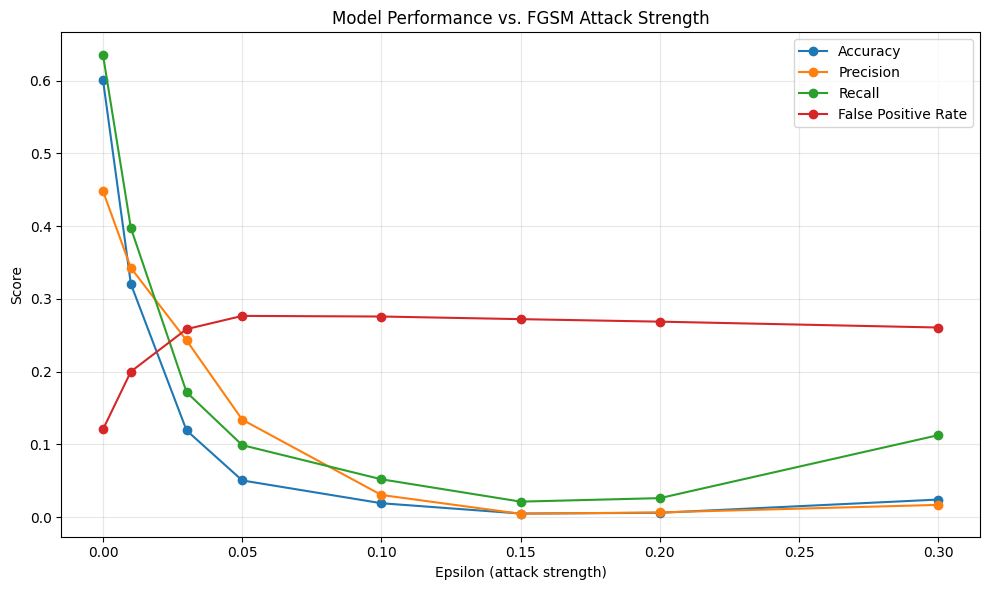

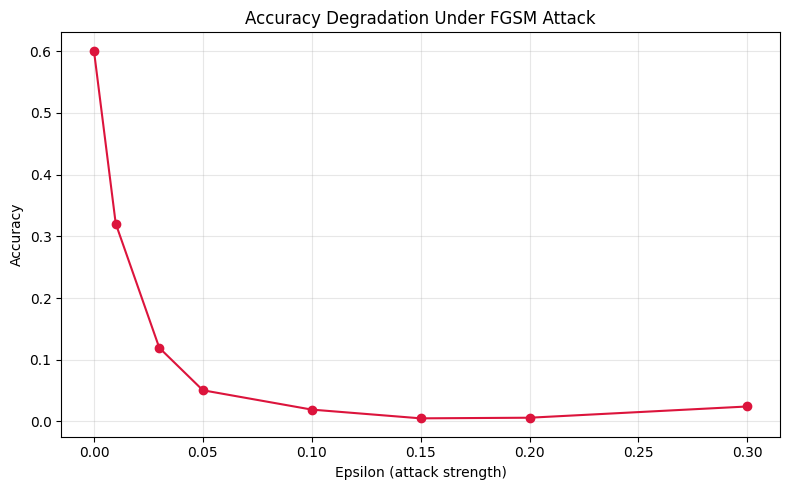

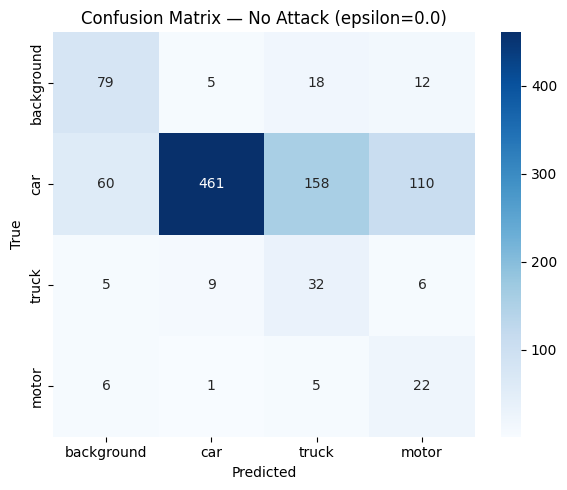

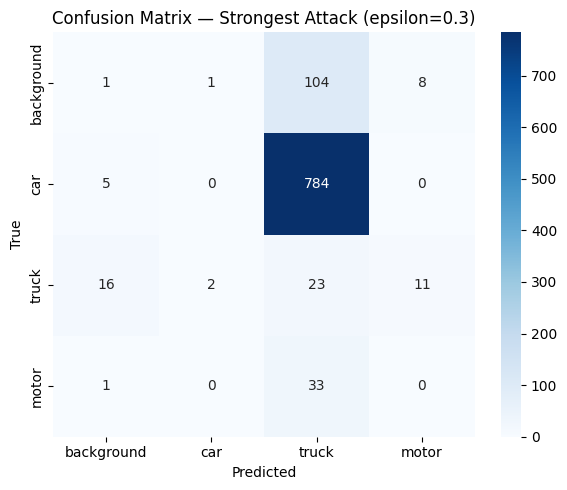


All done.


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import cv2
import urllib.request
import zipfile
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns

print("--- Starting FGSM Adversarial Attack (VisDrone Multi-Class) ---")
print("TensorFlow Version:", tf.__version__)

# ===========================================================
# 1. Download VisDrone2019-DET-val (the smaller split — good for a quick demo)
# ===========================================================
url = "https://github.com/ultralytics/yolov5/releases/download/v1.0/VisDrone2019-DET-val.zip"
zip_path = "VisDrone2019-DET-val.zip"

if not os.path.exists(zip_path):
    print("Downloading VisDrone val set...")
    urllib.request.urlretrieve(url, zip_path)

if not os.path.exists("VisDrone2019-DET-val"):
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")

# --- Verify structure before continuing ---
print("\nFolder structure:")
for root, dirs, files in os.walk("VisDrone2019-DET-val"):
    print(root, "->", files[:5])

IMAGES_DIR = "VisDrone2019-DET-val/images"
ANNOTATIONS_DIR = "VisDrone2019-DET-val/annotations"
# If the printed structure above doesn't match these two paths, fix them here before continuing.

# ===========================================================
# 2. Load car / truck / motor / background crops
# ===========================================================
# Raw VisDrone class IDs (1-indexed; 0 = ignored region): 4=car, 6=truck, 10=motor
VISDRONE_CLASS_MAP = {4: "car", 6: "truck", 10: "motor"}
CLASS_NAMES = ["background", "car", "truck", "motor"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

IMG_SIZE = 64
MIN_BOX_SIZE = 40  # skip boxes smaller than this (in original image pixels) — tiny boxes just become blur when resized up

def load_crops(images_dir, annotations_dir, max_images=400):
    crops, labels = [], []
    ann_files = glob.glob(os.path.join(annotations_dir, "*.txt"))

    for ann_path in ann_files[:max_images]:
        base = os.path.splitext(os.path.basename(ann_path))[0]
        img_path = os.path.join(images_dir, base + ".jpg")
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        with open(ann_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split(",")
            if len(parts) < 8:
                continue
            x, y, bw, bh, score, cls_id, trunc, occ = map(int, parts[:8])
            if cls_id not in VISDRONE_CLASS_MAP or bw <= 0 or bh <= 0:
                continue
            if bw < MIN_BOX_SIZE or bh < MIN_BOX_SIZE:
                continue

            crop = img[max(y, 0):y + bh, max(x, 0):x + bw]
            if crop.size == 0:
                continue
            crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
            crops.append(crop)
            labels.append(CLASS_TO_IDX[VISDRONE_CLASS_MAP[cls_id]])

        # one background patch per image (random no-object crop)
        bg_x = np.random.randint(0, max(w - IMG_SIZE, 1))
        bg_y = np.random.randint(0, max(h - IMG_SIZE, 1))
        bg_crop = img[bg_y:bg_y + IMG_SIZE, bg_x:bg_x + IMG_SIZE]
        if bg_crop.shape[:2] == (IMG_SIZE, IMG_SIZE):
            crops.append(bg_crop)
            labels.append(CLASS_TO_IDX["background"])

    return crops, labels

print("\nLoading crops for car / truck / motor / background...")
crops, labels = load_crops(IMAGES_DIR, ANNOTATIONS_DIR, max_images=550)  # VisDrone val set has 548 images total — scan all of it

X = np.array(crops, dtype=np.float32) / 255.0
y = np.array(labels)
print("Class counts:", {name: int(np.sum(y == idx)) for name, idx in CLASS_TO_IDX.items()})

idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, x_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training class counts:", {name: int(np.sum(y_train == i)) for name, i in CLASS_TO_IDX.items()})
print("Test class counts:", {name: int(np.sum(y_test == i)) for name, i in CLASS_TO_IDX.items()})

# Class weighting — without this, an imbalanced dataset (e.g. way more "car" than "motor")
# biases the model toward guessing the majority class whenever it's unsure.
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# ===========================================================
# 3. Build and train the reference model
# ===========================================================
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\nTraining reference model...")

# Data augmentation — artificially expands training data via random flips/rotations/zooms,
# especially helpful for underrepresented classes like motor/truck.
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(x_train)

model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=8,
    validation_data=(x_test, y_test),
    class_weight=class_weight_dict
)

# ===========================================================
# 4. FGSM — single example demo (visual sanity check)
# ===========================================================
def create_adversarial_pattern(input_image, input_label):
    input_image = tf.cast(input_image, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = model(input_image)
        loss = tf.keras.losses.sparse_categorical_crossentropy(input_label, prediction)
    gradient = tape.gradient(loss, input_image)
    return tf.sign(gradient)

image = x_test[0:1]
label = y_test[0:1]

print("\nGenerating adversarial noise pattern (single example)...")
perturbations = create_adversarial_pattern(image, label)

epsilon_demo = 0.15
adversarial_image = tf.clip_by_value(image + epsilon_demo * perturbations, 0, 1)

print("SUCCESS: Adversarial Perturbation completed successfully!")

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.title(f"Original ({CLASS_NAMES[np.argmax(model.predict(image, verbose=0))]})")
plt.imshow(image[0])

plt.subplot(1, 3, 2)
plt.title("Adversarial Noise")
plt.imshow((perturbations[0] + 1) / 2)  # noise is in [-1,1] (from tf.sign); rescale to [0,1] for clean display

plt.subplot(1, 3, 3)
plt.title(f"Attacked ({CLASS_NAMES[np.argmax(model.predict(adversarial_image, verbose=0))]})")
plt.imshow(adversarial_image[0])
plt.tight_layout()
plt.show()

# ===========================================================
# 5. FGSM across multiple epsilon values on the FULL test set
# ===========================================================
def fgsm_attack_batch(images, labels, epsilon):
    images_tensor = tf.cast(images, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(images_tensor)
        predictions = model(images_tensor)
        loss = tf.keras.losses.sparse_categorical_crossentropy(labels, predictions)
    gradients = tape.gradient(loss, images_tensor)
    signed_grad = tf.sign(gradients)
    adv_images = images_tensor + epsilon * signed_grad
    return tf.clip_by_value(adv_images, 0, 1)

def compute_false_positive_rate(y_true, y_pred, num_classes):
    """Macro-averaged false positive rate across all classes (one-vs-rest)."""
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    fpr_per_class = []
    total = cm.sum()
    for i in range(num_classes):
        fp = cm[:, i].sum() - cm[i, i]
        tn = total - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fpr_per_class.append(fpr)
    return np.mean(fpr_per_class)

epsilons = [0.0, 0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3]
results = {"epsilon": [], "accuracy": [], "precision": [], "recall": [], "fpr": []}
predictions_by_epsilon = {}

print("\nRunning FGSM across epsilon values on the full test set...")
for eps in epsilons:
    adv_x_test = fgsm_attack_batch(x_test, y_test, eps)
    preds = model.predict(adv_x_test, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    predictions_by_epsilon[eps] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    fpr = compute_false_positive_rate(y_test, y_pred, len(CLASS_NAMES))

    results["epsilon"].append(eps)
    results["accuracy"].append(acc)
    results["precision"].append(prec)
    results["recall"].append(rec)
    results["fpr"].append(fpr)

    print(f"epsilon={eps:.2f} | acc={acc:.3f} | precision={prec:.3f} | recall={rec:.3f} | FPR={fpr:.3f}")

# ===========================================================
# 6. Graph the results
# ===========================================================
plt.figure(figsize=(10, 6))
plt.plot(results["epsilon"], results["accuracy"], marker='o', label="Accuracy")
plt.plot(results["epsilon"], results["precision"], marker='o', label="Precision")
plt.plot(results["epsilon"], results["recall"], marker='o', label="Recall")
plt.plot(results["epsilon"], results["fpr"], marker='o', label="False Positive Rate")
plt.xlabel("Epsilon (attack strength)")
plt.ylabel("Score")
plt.title("Model Performance vs. FGSM Attack Strength")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results["epsilon"], results["accuracy"], marker='o', color='crimson')
plt.xlabel("Epsilon (attack strength)")
plt.ylabel("Accuracy")
plt.title("Accuracy Degradation Under FGSM Attack")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===========================================================
# 7. Confusion matrices — baseline (epsilon=0) vs. strongest attack
# ===========================================================
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

baseline_eps = epsilons[0]
strongest_eps = epsilons[-1]

plot_confusion_matrix(
    y_test, predictions_by_epsilon[baseline_eps], CLASS_NAMES,
    f"Confusion Matrix — No Attack (epsilon={baseline_eps})"
)

plot_confusion_matrix(
    y_test, predictions_by_epsilon[strongest_eps], CLASS_NAMES,
    f"Confusion Matrix — Strongest Attack (epsilon={strongest_eps})"
)

